# Importing Libraries and Dataset

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import folium
import matplotlib.pyplot as plt

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/ba305_project/bank-full.csv'
df = pd.read_csv(path, sep=';')

# Display the first few rows
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Exploratory Data Analysis (EDA) Data Overview

In [ ]:
print('DataFrame Info:')
df.info()

print('\nDataFrame Description:')
display(df.describe(include='all'))

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

DataFrame Description:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


### Target Variable Distribution

Now, let's examine the distribution of our target variable, `y` (whether a deposit was accepted or not).

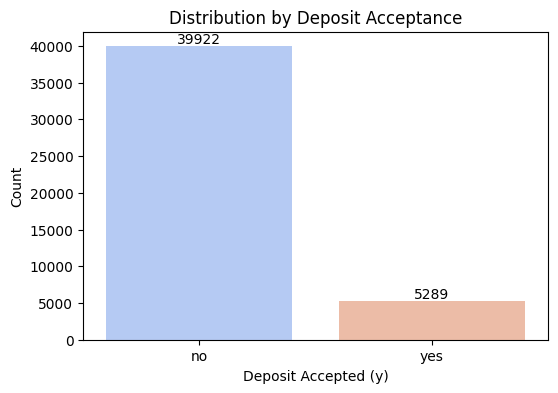

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='y', data=df, palette = 'coolwarm') # Using original df to display 'yes' and 'no' labels
plt.title('Distribution by Deposit Acceptance') #Grouped by whether or not the client accepted the deposit
plt.xlabel('Deposit Accepted (y)')
plt.ylabel('Count')

# Adding counts above the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

Let's convert the target variable `y` into binary entries (0 for 'no' and 1 for 'yes') and then display its distribution as percentages.

In [ ]:
# Convert 'y' to binary (0 for 'no', 1 for 'yes')
df_binary_y = df.copy() # Create a copy to avoid modifying the original dataframe for this calculation
df_binary_y['y_binary'] = df_binary_y['y'].map({'no': 0, 'yes': 1})

# Calculate the percentage of each binary value
percentage_distribution = df_binary_y['y_binary'].value_counts(normalize=True) * 100

print("Percentage distribution of 'y' (0: No Deposit, 1: Yes Deposit):")
print(percentage_distribution)

Percentage distribution of 'y' (0: No Deposit, 1: Yes Deposit):
y_binary
0    88.30152
1    11.69848
Name: proportion, dtype: float64


### Feature Analysis: Job vs. Deposit Acceptance

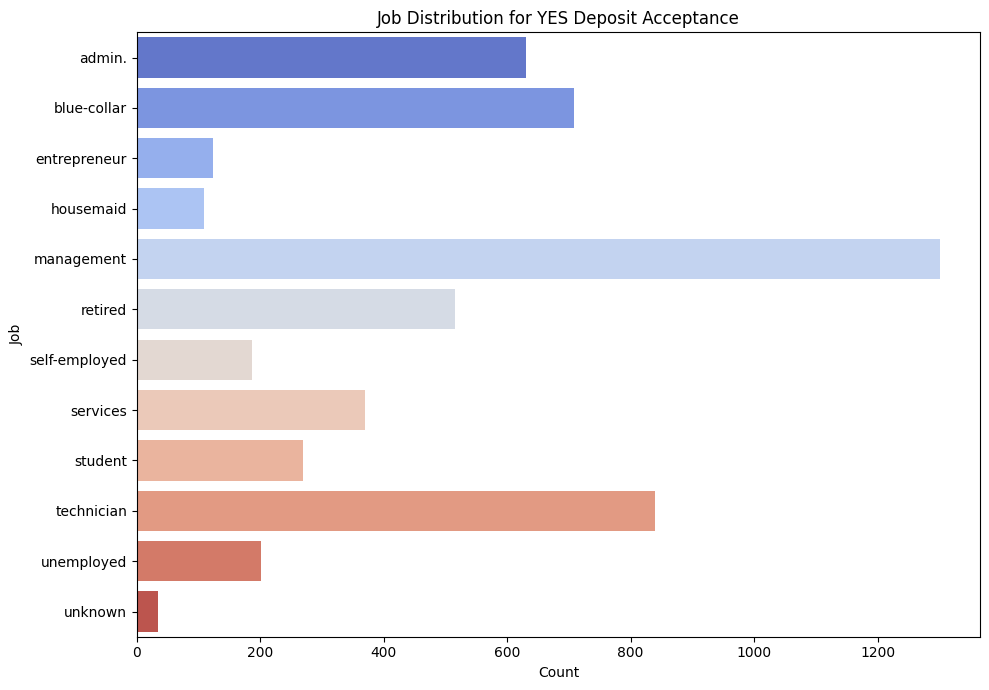

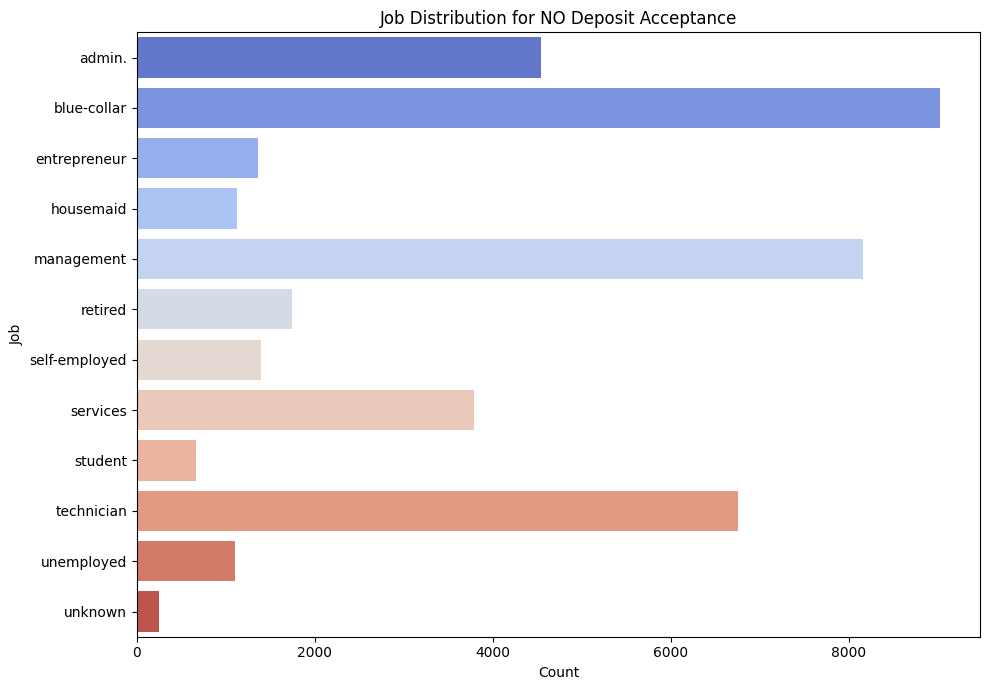

In [ ]:
# Job vs. Deposit Acceptance (y)
job_deposit_counts = df.groupby(['job', 'y']).size().unstack(fill_value=0)

# Plot for 'yes' deposit acceptance by count
plt.figure(figsize=(10, 7))
sns.barplot(x=job_deposit_counts['yes'], y=job_deposit_counts.index, palette = 'coolwarm')
plt.title('Job Distribution for YES Deposit Acceptance')
plt.xlabel('Count')
plt.ylabel('Job')
plt.tight_layout()
plt.show()

# Plot for 'no' deposit acceptance by count
plt.figure(figsize=(10, 7))
sns.barplot(x=job_deposit_counts['no'], y=job_deposit_counts.index, palette = 'coolwarm')
plt.title('Job Distribution for NO Deposit Acceptance')
plt.xlabel('Count')
plt.ylabel('Job')
plt.tight_layout()
plt.show()

### Job vs. Deposit Acceptance - Count Distribution

Let's also visualize the absolute counts of 'yes' and 'no' deposit acceptance for each job category as stacked bars.

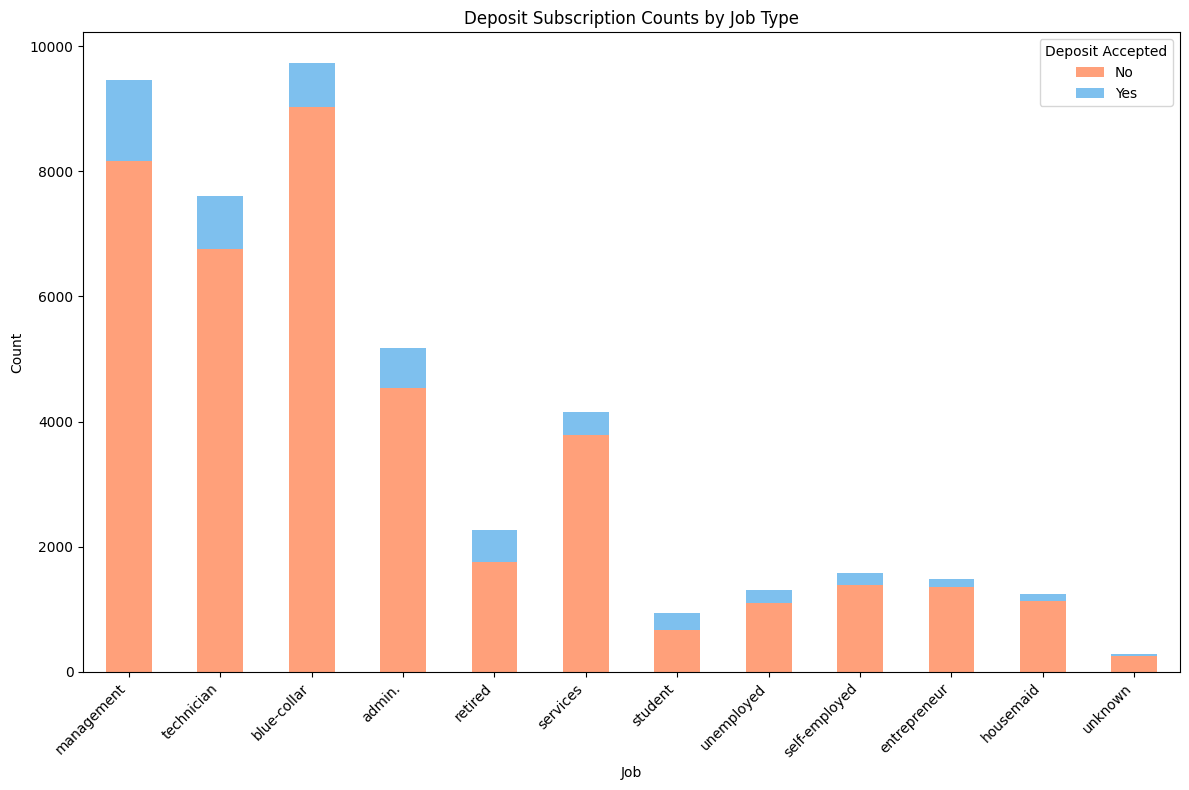

In [ ]:
# Calculate counts of 'yes' and 'no' for each job
job_deposit_counts_stacked = df.groupby('job')['y'].value_counts().unstack(fill_value=0)

# Sort by total count of 'yes' for better visualization
job_deposit_counts_stacked = job_deposit_counts_stacked.sort_values(by='yes', ascending=False)

# Plotting the stacked bar chart
plt.figure(figsize=(12, 8))
job_deposit_counts_stacked.plot(kind='bar', stacked=True, color={'no': '#FFA07A', 'yes': '#7EC0EE'}, ax=plt.gca())
plt.title('Deposit Subscription Counts by Job Type')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Deposit Accepted', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

### Feature Analysis: Age vs. Deposit Acceptance

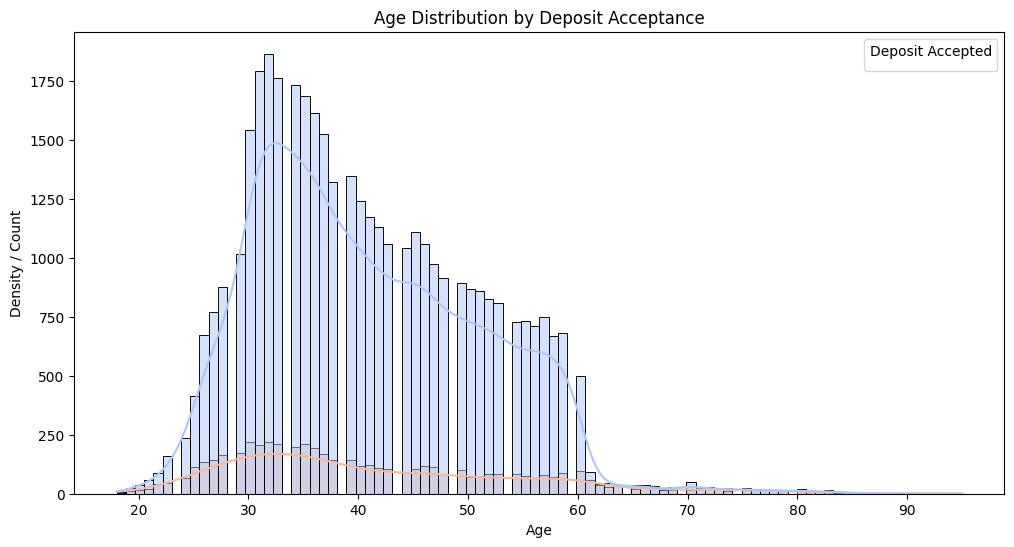

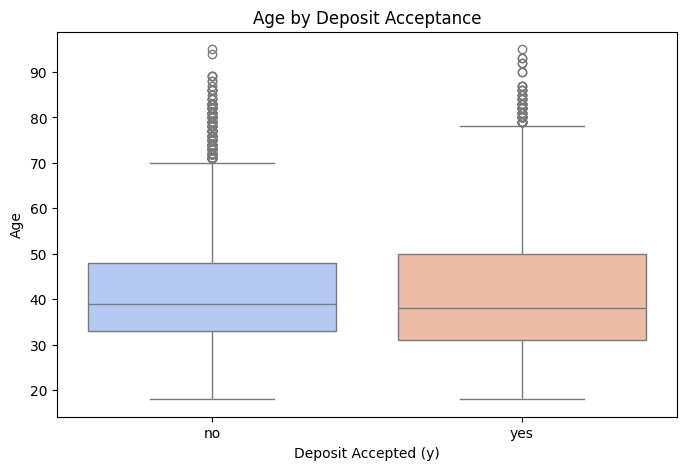

In [ ]:
# Age Distribution by Deposit Acceptance (y)
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='age', hue='y', kde=True, palette = 'coolwarm')
plt.title('Age Distribution by Deposit Acceptance')
plt.xlabel('Age')
plt.ylabel('Density / Count')
plt.legend(title='Deposit Accepted')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='age', data=df, palette = 'coolwarm')
plt.title('Age by Deposit Acceptance')
plt.xlabel('Deposit Accepted (y)')
plt.ylabel('Age')
plt.show()

### Age Group Distribution by Deposit Acceptance

To better understand the relationship between age and deposit acceptance, let's categorize age into groups and visualize their distribution.

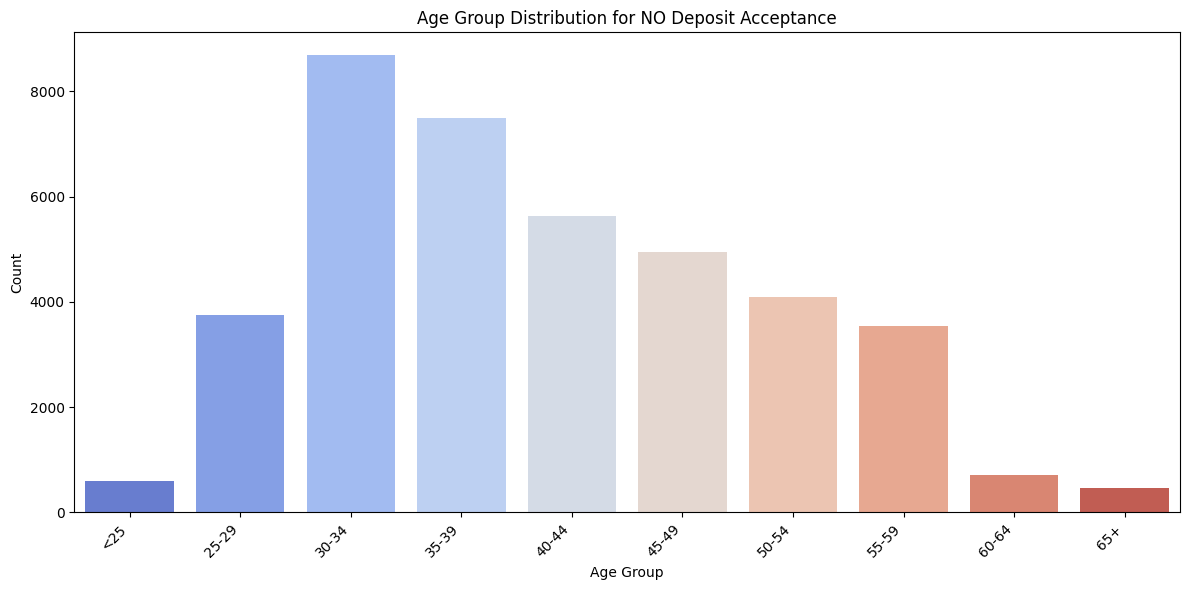

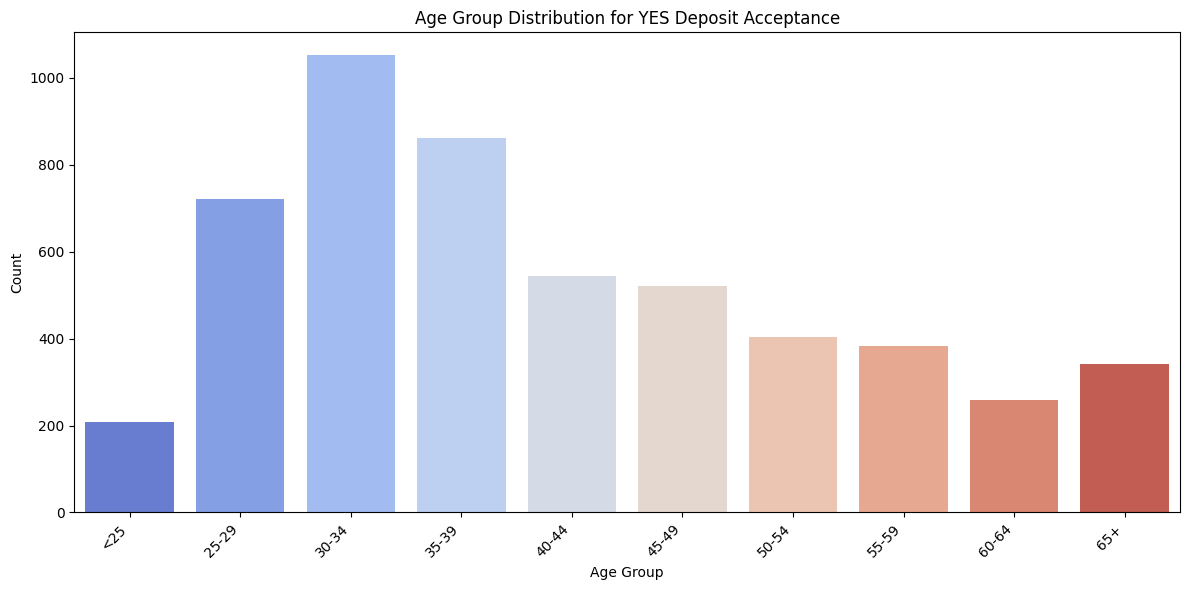

In [ ]:
# Define age bins and labels
age_bins = [0, 25, 30, 35, 40, 45, 50, 55, 60, 65, float('inf')]
age_labels = ['<25', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65+']

# Create a new column for age groups
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Calculate counts of deposit acceptance for each age group
age_group_y_counts = df.groupby(['age_group', 'y']).size().unstack(fill_value=0)

# Plot for 'no' deposit acceptance by age group
plt.figure(figsize=(12, 6))
sns.barplot(x=age_group_y_counts.index, y=age_group_y_counts['no'], palette='coolwarm', order=age_labels)
plt.title('Age Group Distribution for NO Deposit Acceptance')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot for 'yes' deposit acceptance by age group
plt.figure(figsize=(12, 6))
sns.barplot(x=age_group_y_counts.index, y=age_group_y_counts['yes'], palette='coolwarm', order=age_labels)
plt.title('Age Group Distribution for YES Deposit Acceptance')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Feature Analysis: Call Duration vs. Deposit Acceptance

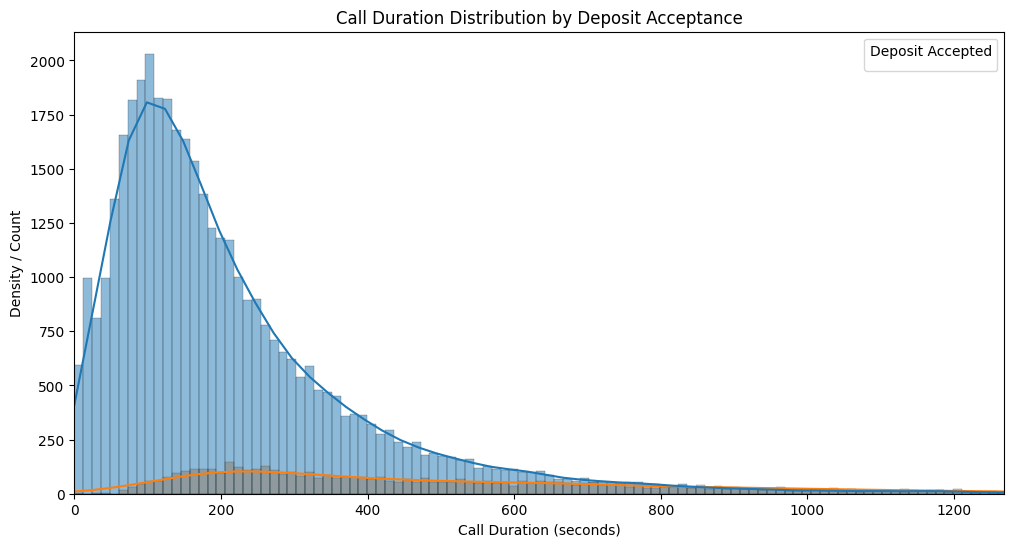

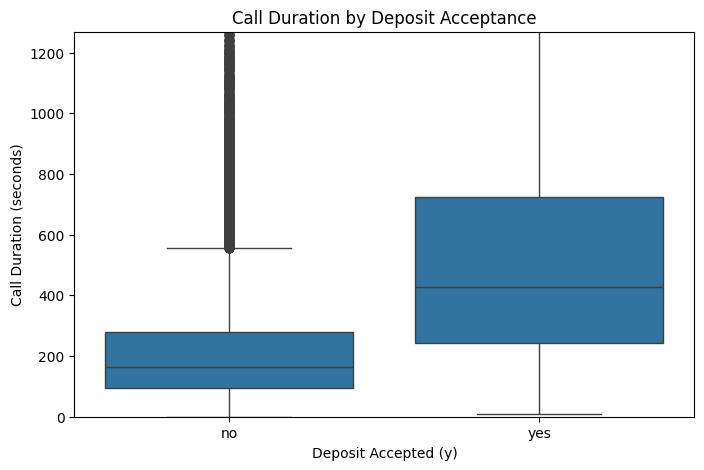

In [ ]:
# Call Duration vs. Deposit Acceptance (y)
# Note: 'duration' can be a data leakage feature for prediction, as a successful deposit implies a non-zero duration.

# Calculate the 99th percentile for duration to set a reasonable upper limit for the plots
duration_limit = df['duration'].quantile(0.99)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='duration', hue='y', kde=True)
plt.title('Call Duration Distribution by Deposit Acceptance')
plt.xlabel('Call Duration (seconds)')
plt.ylabel('Density / Count')
plt.xlim(0, duration_limit) # Set x-axis limit to focus on non-outlier data
plt.legend(title='Deposit Accepted')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='duration', data=df)
plt.title('Call Duration by Deposit Acceptance')
plt.xlabel('Deposit Accepted (y)')
plt.ylabel('Call Duration (seconds)')
plt.ylim(0, duration_limit) # Set y-axis limit to focus on non-outlier data
plt.show()

### Feature Analysis: Previous Campaign Outcome vs. Deposit Acceptance

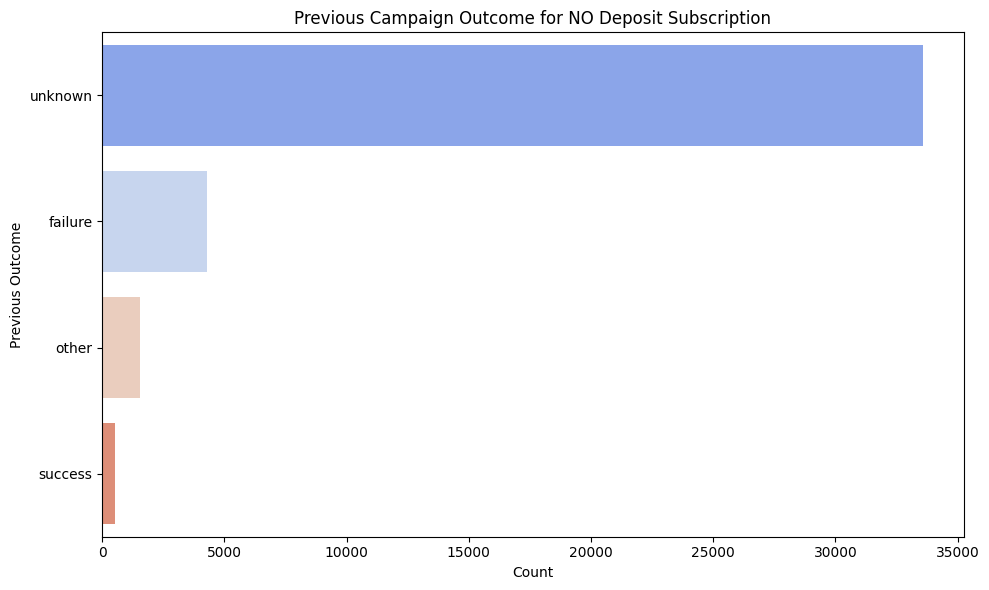

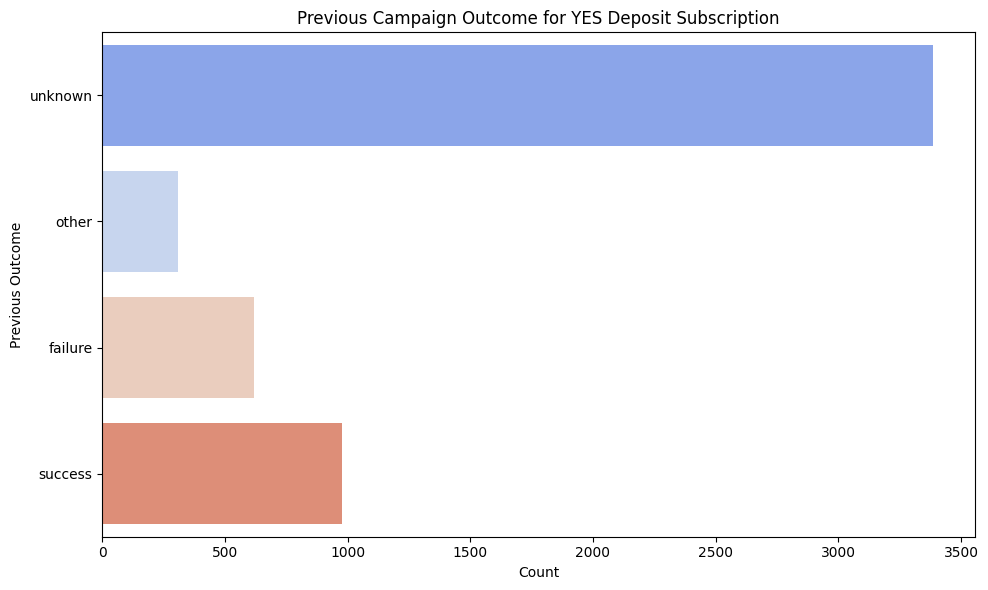

,count
poutcome,
unknown,33573
failure,4283
other,1533
success,533


In [ ]:
# Previous Campaign Outcome (poutcome) vs. Deposit Acceptance (y)

# Plot for 'no' deposit acceptance by previous campaign outcome
plt.figure(figsize=(10, 6))
sns.countplot(y='poutcome', data=df[df['y'] == 'no'], palette='coolwarm')
plt.title('Previous Campaign Outcome for NO Deposit Subscription')
plt.xlabel('Count')
plt.ylabel('Previous Outcome')
plt.tight_layout()
plt.show()

# Plot for 'yes' deposit acceptance by previous campaign outcome
plt.figure(figsize=(10, 6))
sns.countplot(y='poutcome', data=df[df['y'] == 'yes'], palette='coolwarm')
plt.title('Previous Campaign Outcome for YES Deposit Subscription')
plt.xlabel('Count')
plt.ylabel('Previous Outcome')
plt.tight_layout()
plt.show()

df[df['y'] == 'no']['poutcome'].value_counts()

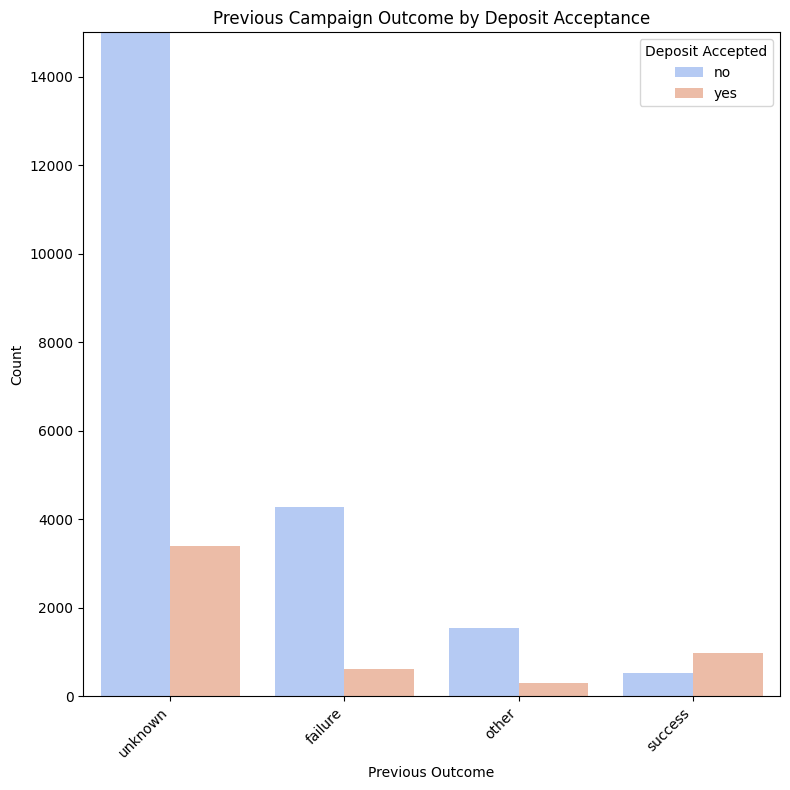

In [ ]:
plt.figure(figsize=(8, 8)) # Adjust figure size for a square aspect ratio
sns.countplot(x='poutcome', hue='y', data=df, palette='coolwarm')
plt.title('Previous Campaign Outcome by Deposit Acceptance')
plt.xlabel('Previous Outcome')
plt.ylabel('Count')
plt.legend(title='Deposit Accepted')
plt.ylim(0, 15000) # Set the y-axis limit to zoom in
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

### Previous Campaign Outcome (poutcome) vs. Deposit Acceptance (y) - Excluding 'unknown'

Given that 'unknown' is a dominant category, let's analyze the distribution of other previous campaign outcomes more closely by filtering out the 'unknown' entries.

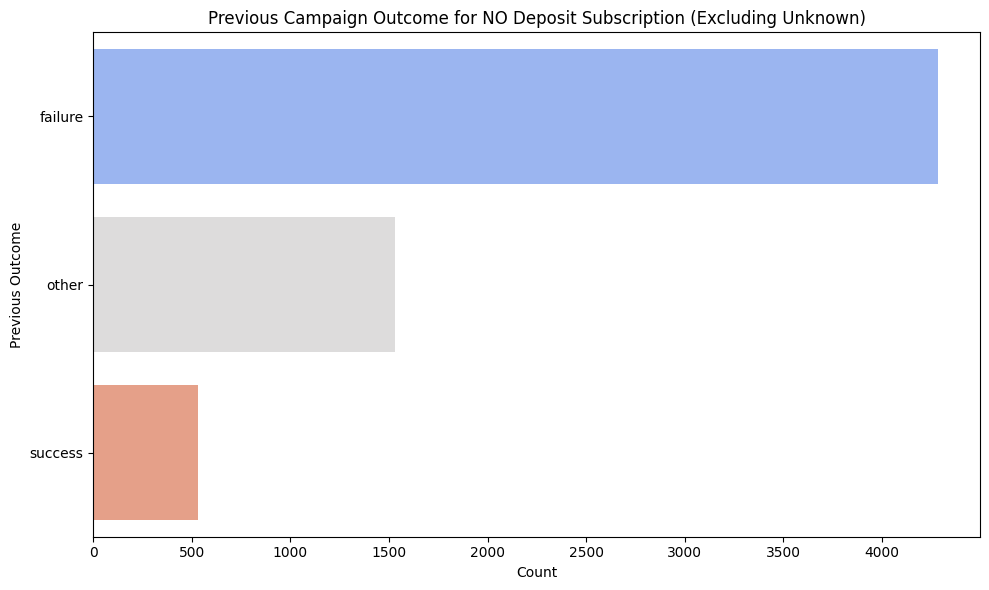

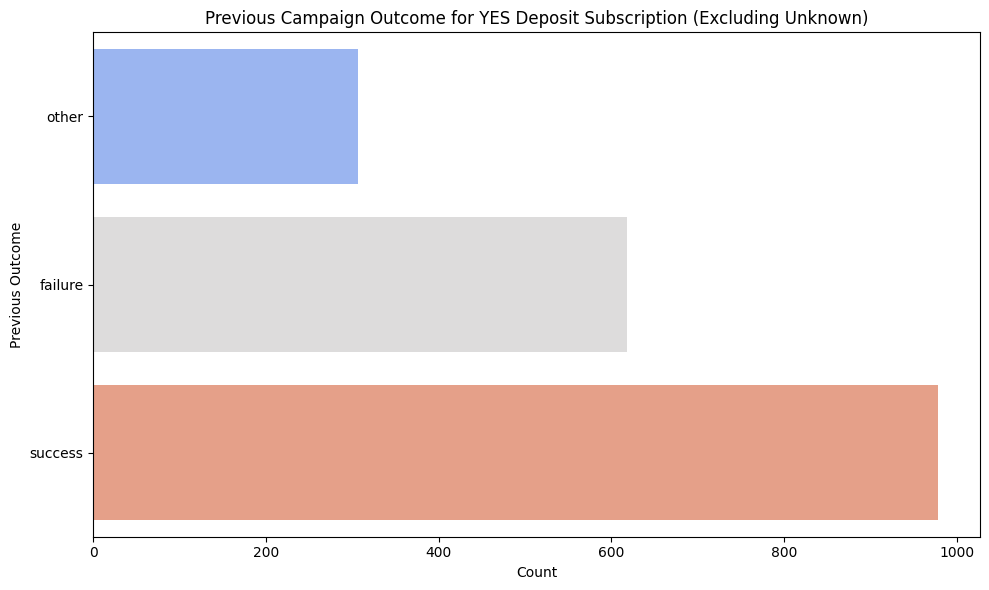

In [ ]:
# Filter out 'unknown' from the 'poutcome' column
df_filtered_poutcome = df[df['poutcome'] != 'unknown'].copy()

# Plot for 'no' deposit acceptance by filtered previous campaign outcome
plt.figure(figsize=(10, 6))
sns.countplot(y='poutcome', data=df_filtered_poutcome[df_filtered_poutcome['y'] == 'no'], palette='coolwarm')
plt.title('Previous Campaign Outcome for NO Deposit Subscription (Excluding Unknown)')
plt.xlabel('Count')
plt.ylabel('Previous Outcome')
plt.tight_layout()
plt.show()

# Plot for 'yes' deposit acceptance by filtered previous campaign outcome
plt.figure(figsize=(10, 6))
sns.countplot(y='poutcome', data=df_filtered_poutcome[df_filtered_poutcome['y'] == 'yes'], palette='coolwarm')
plt.title('Previous Campaign Outcome for YES Deposit Subscription (Excluding Unknown)')
plt.xlabel('Count')
plt.ylabel('Previous Outcome')
plt.tight_layout()
plt.show()

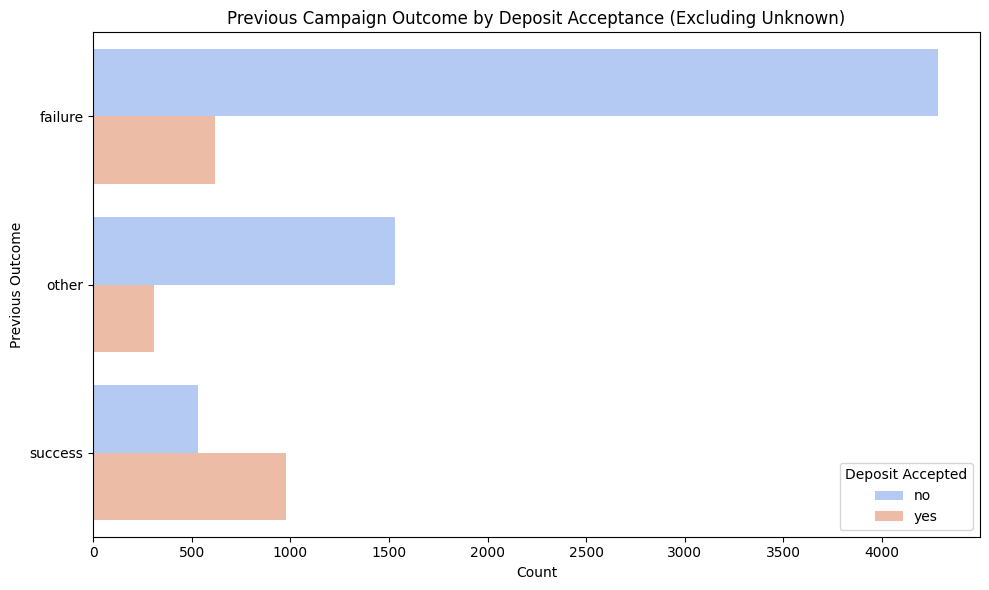

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='poutcome', hue='y', data=df_filtered_poutcome, palette='coolwarm')
plt.title('Previous Campaign Outcome by Deposit Acceptance (Excluding Unknown)')
plt.xlabel('Count')
plt.ylabel('Previous Outcome')
plt.legend(title='Deposit Accepted')
plt.tight_layout()
plt.show()